# Deutsch-Jozsa Algorithm

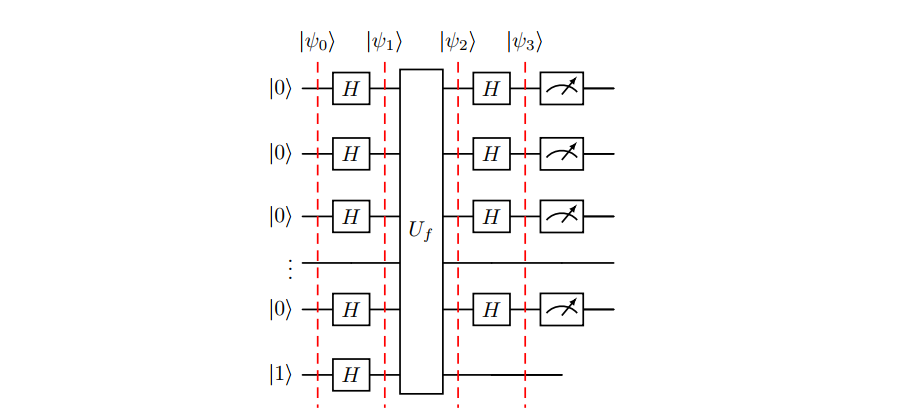

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualization Function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=False, initial_state = True)

## Function Balanced

- __f(000) = 1__,
- f(001) = 0,
- __f(010) = 1__,
- f(011) = 0,
- __f(100) = 1__,
- f(101) = 0,
- __f(110) = 1__,
- f(111) = 1

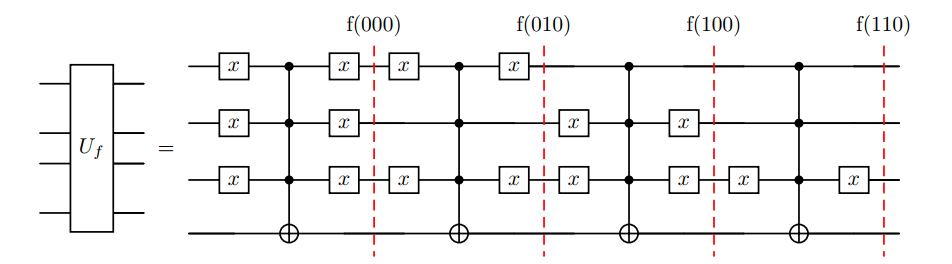

In [5]:
# create the main register
qm = QuantumRegister(3, name = 'qubit')
# create the ancillar register
qa = QuantumRegister(1, name = 'ancilla')

# create the classical register for measurement
cbits = ClassicalRegister(3, name = 'bits')

In [25]:
# Create the quantum Circuit
qc = QuantumCircuit(qm, qa, cbits)

# initialization of ancillary qubit
qc.x(qa)
qc.barrier(label = '|->')

# Apply Hadard to all qubits
qc.h(range(4))
qc.barrier(label = 'H^4')

# Apply oracle
## First step for f(000)
qc.x(qm)
qc.mcx(qm, qa)
qc.x(qm)
qc.barrier(label = 'f(000)')

## Second Step for f(010)

qc.x(qm[0])
qc.x(qm[2])
qc.mcx(qm, qa)
qc.x(qm[0])
qc.x(qm[2])
qc.barrier(label = 'f(010)')

## Third step for f(100)
qc.x(qm[1])
qc.x(qm[2])
qc.mcx(qm, qa)
qc.x(qm[1])
qc.x(qm[2])
qc.barrier(label = 'f(100)')


## Third step for f(110)
qc.x(qm[2])
qc.mcx(qm, qa)
qc.x(qm[2])
qc.barrier(label = 'f(110)')
qc.barrier(label= 'end of Oracle')

# Apply Hadamard
qc.h(qm)
qc.barrier()

# Measurement
for i in range(len(qm)):
    qc.measure(qm[i], cbits[i])


qplot(qc)

|-> ┌───┐ H^4 ┌───┐     ┌───┐ f(000) ┌───┐     ┌───┐ f(010)                 f(100)                 f(110)  end of Oracle ┌───┐ ░ ┌─┐      
qubit_0: |0>───────░──┤ H ├──░──┤ X ├──■──┤ X ├───░────┤ X ├──■──┤ X ├───░───────────■──────────░───────────■──────────░───────────░───────┤ H ├─░─┤M├──────
                   ░  ├───┤  ░  ├───┤  │  ├───┤   ░    └───┘  │  └───┘   ░    ┌───┐  │  ┌───┐   ░           │          ░           ░       ├───┤ ░ └╥┘┌─┐   
qubit_1: |0>───────░──┤ H ├──░──┤ X ├──■──┤ X ├───░───────────■──────────░────┤ X ├──■──┤ X ├───░───────────■──────────░───────────░───────┤ H ├─░──╫─┤M├───
                   ░  ├───┤  ░  ├───┤  │  ├───┤   ░    ┌───┐  │  ┌───┐   ░    ├───┤  │  ├───┤   ░    ┌───┐  │  ┌───┐   ░           ░       ├───┤ ░  ║ └╥┘┌─┐
qubit_2: |0>───────░──┤ H ├──░──┤ X ├──■──┤ X ├───░────┤ X ├──■──┤ X ├───░────┤ X ├──■──┤ X ├───░────┤ X ├──■──┤ X ├───░───────────░───────┤ H ├─░──╫──╫─┤M├
            ┌───┐  ░  ├───┤  ░  └───┘┌─┴─┐└───┘   ░    └───┘┌─┴─┐└───┘   ░    └───┘┌─┴─┐└───┘   ░    └───┘┌─┴─┐└───┘   ░           ░       └───┘ ░  ║  ║ └╥┘
ancilla: |0>┤ X ├──░──┤ H ├──░───────┤ X ├────────░─────────┤ X ├────────░─────────┤ X ├────────░─────────┤ X ├────────░───────────░─────────────░──╫──╫──╫─
            └───┘  ░  └───┘  ░       └───┘        ░         └───┘        ░         └───┘        ░         └───┘        ░           ░             ░  ║  ║  ║ 
  bits_0: 0 ════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╬══╬═
                                                                                                                                                       ║  ║ 
  bits_1: 0 ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╬═
                                                                                                                                                          ║ 
  bits_2: 0 ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩═

In [28]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc, shots = 2000)
result = job.result()
counts = result.get_counts()
counts 

{'100': 2000}

## Constant Oracle 
$$f(000) = f(001) = \cdots = f(111) =0   $$

In [29]:
# Create the quantum Circuit
qc = QuantumCircuit(qm, qa, cbits)

# initialization of ancillary qubit
qc.x(qa)
qc.barrier(label = '|->')

# Apply Hadard to all qubits
qc.h(range(4))
qc.barrier(label = 'H^4')

# Apply oracle

# Apply Hadamard
qc.h(qm)
qc.barrier()

# Measurement
for i in range(len(qm)):
    qc.measure(qm[i], cbits[i])


qplot(qc)

|-> ┌───┐ H^4 ┌───┐ ░ ┌─┐      
qubit_0: |0>───────░──┤ H ├──░──┤ H ├─░─┤M├──────
                   ░  ├───┤  ░  ├───┤ ░ └╥┘┌─┐   
qubit_1: |0>───────░──┤ H ├──░──┤ H ├─░──╫─┤M├───
                   ░  ├───┤  ░  ├───┤ ░  ║ └╥┘┌─┐
qubit_2: |0>───────░──┤ H ├──░──┤ H ├─░──╫──╫─┤M├
            ┌───┐  ░  ├───┤  ░  └───┘ ░  ║  ║ └╥┘
ancilla: |0>┤ X ├──░──┤ H ├──░────────░──╫──╫──╫─
            └───┘  ░  └───┘  ░        ░  ║  ║  ║ 
  bits_0: 0 ═════════════════════════════╩══╬══╬═
                                            ║  ║ 
  bits_1: 0 ════════════════════════════════╩══╬═
                                               ║ 
  bits_2: 0 ═══════════════════════════════════╩═

In [30]:

transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc, shots = 2000)
result = job.result()
counts = result.get_counts()
counts 

{'000': 2000}